In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import warnings

from scqat.protocols.qubit_decoherence import QubitDecoherenceAnalyzer
from scqat.math_tools.fit_qubit_decoherence import rho11_model, rho10_model, FitQubitDecoherence
from scqat.math_tools.fit_multi_damped_oscillation import FitMultiDampedOscillation, multi_damped_osc_eval
from scqat.protocols.hankel_analysis import HankelAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
import os
from scqat.parsers.qualibrate_parser import repetition_data, parse_timestamp

In [2]:
# Define the path to the h5 file
# h5_file_path = r'/Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1512_LCH_qubit_parametric_drive_time_tomo_4_232122/ds_raw.h5'
h5_file_path = r'/Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1519_LCH_qubit_parametric_drive_time_tomo_11_002823/ds_raw.h5'
# Check if file exists
if os.path.exists(h5_file_path):
    print(f"Found h5 file: {h5_file_path}")
else:
    print(f"File not found: {h5_file_path}")
    print(f"Current directory: {os.getcwd()}")
    print("Available files in current directory:")
    for file in os.listdir('.'):
        if file.endswith('.h5'):
            print(f"  - {file}")

# Load data using the qcat parser
try:
    ds = load_xarray_h5(h5_file_path)
    print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")
    print(f"Coordinates: {list(ds.coords.keys())}")
    print(f"Data variables: {list(ds.data_vars.keys())}")
    
    # Check if it has multiple qubits/repetitions
    if 'qubit' in ds.dims:
        print(f"\nFound {ds.sizes['qubit']} qubits in the dataset")
        qubit_data = repetition_data(ds, repetition_dim="qubit")
        print(f"Separated data into {len(qubit_data)} individual qubit datasets")
    else:
        qubit_data = [ds]  # Single dataset
        print("Single dataset (no qubit dimension)")
        
except Exception as e:
    print(f"Error loading file: {e}")
    ds = None

print(ds)

Found h5 file: /Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1519_LCH_qubit_parametric_drive_time_tomo_11_002823/ds_raw.h5
Successfully loaded dataset with dimensions: {'driving_time': 150, 'driving_frequency': 11, 'basis': 3, 'qubit': 1}
Coordinates: ['driving_time', 'driving_frequency', 'basis', 'qubit']
Data variables: ['state']

Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets
<xarray.Dataset> Size: 40kB
Dimensions:            (driving_time: 150, driving_frequency: 11, basis: 3,
                        qubit: 1)
Coordinates:
  * driving_time       (driving_time) int32 600B 20 60 100 ... 5900 5940 5980
  * driving_frequency  (driving_frequency) float64 88B 3.234e+08 ... 3.236e+08
  * basis              (basis) int32 12B 0 1 2
  * qubit              (qubit) object 8B 'q1'
Data variables:
    state              (qubit, driving_frequency, driving_time, basis) float64 40kB ...


/var/folders/gj/5g2p36y973q8qh7rskmqbpp00000gn/T/ipykernel_26737/2153330116.py:18: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")


Creating heatmaps...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Available data variables: ['state']
Available coordinates: ['driving_time', 'driving_frequency', 'basis']


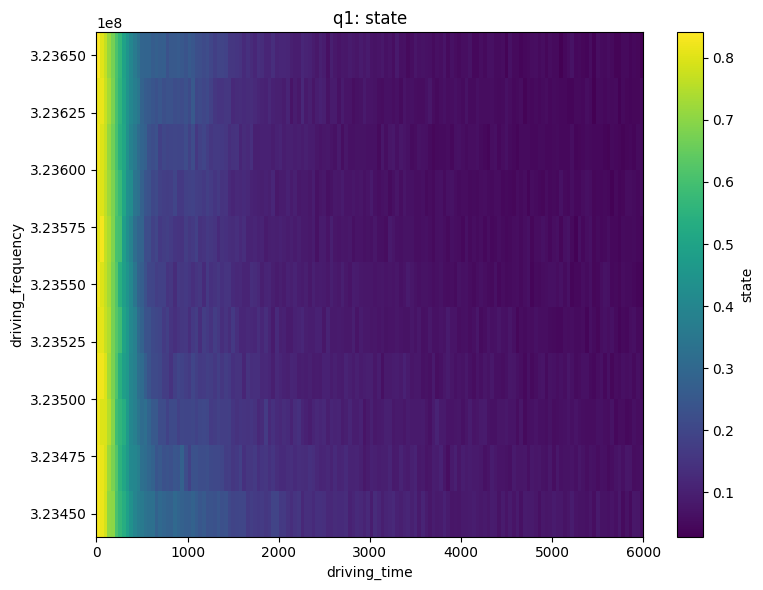


Heatmap creation complete!


In [3]:
print("Creating heatmaps...")

for i, sq_data in enumerate(qubit_data):
    # Select index 2 from basis coordinate if it exists
    if 'basis' in sq_data.coords:
        sq_data = sq_data.isel(basis=2)
        print(f"Selected basis index 2 from coordinate")

    try:
        qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        print(f"\nProcessing qubit {i}: {qubit_name}")
    except Exception:
        qubit_name = f"Dataset_{i}"
        print(f"\nProcessing dataset {i}")

    # Get available data variables and coordinates
    data_vars = list(sq_data.data_vars.keys())
    coords = [c for c in sq_data.coords.keys() if c != 'qubit']
    print(f"Available data variables: {data_vars}")
    print(f"Available coordinates: {coords}")

    # User-specified plotting parameters
    x_dim = "driving_time"
    y_dim = "driving_frequency"
    data_var = "state"

    # Extract the 2D data array and ensure axis ordering (y, x)
    da = sq_data[data_var]
    extra_dims = [d for d in da.dims if d not in (x_dim, y_dim)]
    if extra_dims:
        da = da.isel({d: 0 for d in extra_dims})
    da = da.transpose(y_dim, x_dim)

    x = da[x_dim].values
    y = da[y_dim].values
    Z = da.values

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(x, y, Z, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label=data_var)
    ax.set_xlabel(x_dim)
    ax.set_ylabel(y_dim)
    ax.set_title(f"{qubit_name}: {data_var}")
    plt.tight_layout()
    plt.show()

print("\nHeatmap creation complete!")


Creating 1D line plots (state vs driving_frequency)...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Plotted time: 380.0 ns (requested: 400.0 ns)
Plotted time: 500.0 ns (requested: 500.0 ns)
Plotted time: 580.0 ns (requested: 600.0 ns)
Plotted time: 700.0 ns (requested: 700.0 ns)
Plotted time: 780.0 ns (requested: 800.0 ns)
Plotted time: 900.0 ns (requested: 900.0 ns)
Plotted time: 980.0 ns (requested: 1000.0 ns)
Plotted time: 1100.0 ns (requested: 1100.0 ns)
Plotted time: 1180.0 ns (requested: 1200.0 ns)
Plotted time: 1300.0 ns (requested: 1300.0 ns)
Plotted time: 1380.0 ns (requested: 1400.0 ns)
Target times average: calculated from 11 time points
All times average: calculated from 150 time points


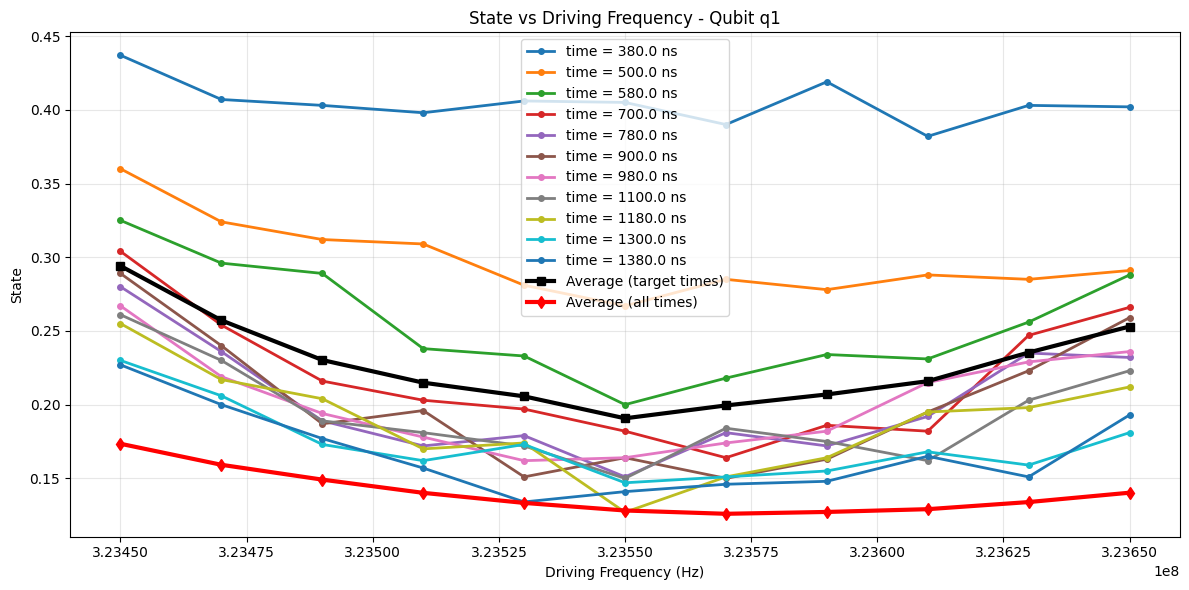

In [4]:
# Plot 1D line graphs for specific driving times
print("Creating 1D line plots (state vs driving_frequency)...")

# User-specified driving times to plot
target_times = [400,500,600,700,800,900,1000,1100,1200,1300,1400]  # Modify this list as needed (in ns)

for i, sq_data in enumerate(qubit_data):
    # Select index 2 from basis coordinate if it exists
    if 'basis' in sq_data.coords:
        sq_data = sq_data.isel(basis=2)
        print(f"Selected basis index 2 from coordinate")
    
    try:
        qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        print(f"\nProcessing qubit {i}: {qubit_name}")
    except:
        print(f"\nProcessing dataset {i}")
    
    # Create figure for line plots
    plt.figure(figsize=(12, 6))
    
    # Get driving_time and driving_frequency arrays
    driving_time = sq_data.coords["driving_time"].values
    driving_freq = sq_data.coords["driving_frequency"].values
    
    # Collect state_data arrays for averaging
    state_data_arrays = []
    
    # Plot line for each target time
    for time in target_times:
        # Find closest time in the data
        time_idx = np.argmin(np.abs(driving_time - time))
        actual_time = driving_time[time_idx]
        
        # Extract state data for this time
        state_data = sq_data["state"].isel(driving_time=time_idx).values
        state_data_arrays.append(state_data)
        
        # Plot the line
        plt.plot(driving_freq, state_data, 'o-', label=f'time = {actual_time:.1f} ns', linewidth=2, markersize=4)
        print(f"Plotted time: {actual_time:.1f} ns (requested: {time:.1f} ns)")
    
    # Calculate average state_data from target times (existing method)
    avg_state_data_target = np.mean(state_data_arrays, axis=0)
    
    # Calculate average state_data across all driving times (new method)
    avg_state_data_all_time = sq_data["state"].mean(dim="driving_time").values
    
    # Plot both averages
    plt.plot(driving_freq, avg_state_data_target, 's-', label='Average (target times)', linewidth=3, markersize=6, color='black')
    plt.plot(driving_freq, avg_state_data_all_time, 'd-', label='Average (all times)', linewidth=3, markersize=6, color='red')
    
    print(f"Target times average: calculated from {len(target_times)} time points")
    print(f"All times average: calculated from {len(driving_time)} time points")
    
    # Format the plot
    plt.xlabel('Driving Frequency (Hz)')
    plt.ylabel('State')
    plt.title(f'State vs Driving Frequency - Qubit {qubit_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



## 5. Per-`driving_frequency` Decoherence Analysis

Construct density-matrix elements from the three tomography rotations stored along
`basis` (X, Y, Z), then fit $\rho_{11}(t)$ versus `driving_time` to the
non-Markovian amplitude-damping model for each `driving_frequency`.

**Conventions used here**
- `basis = 0, 1, 2` correspond to X, Y, Z tomography readouts.
- `state` is $P(\lvert 1\rangle)$ in each rotated frame.
- $\rho_{11} = \text{state}[\text{basis}=2]$.
- $\langle X\rangle = 1 - 2\,\text{state}[0]$, $\langle Y\rangle = 1 - 2\,\text{state}[1]$.
- $\rho_{10} = (\langle X\rangle + i\,\langle Y\rangle)/2$ (computed but not fitted yet).

In [5]:
# --- Build density-matrix datasets per qubit ---
rho_datasets = []  # list of xr.Dataset, one per qubit

for i, sq_data in enumerate(qubit_data):
    if "basis" not in sq_data.coords:
        raise ValueError(f"Dataset {i} has no 'basis' coordinate; cannot build density matrix.")

    state = sq_data["state"]  # dims include: basis, driving_time, driving_frequency, ...

    # Tomography expectation values (drop the scalar 'basis' coord left over from isel)
    X = (1.0 - 2.0 * state.isel(basis=0)).drop_vars("basis", errors="ignore")
    Y = (1.0 - 2.0 * state.isel(basis=1)).drop_vars("basis", errors="ignore")
    rho_11 = (state.isel(basis=2).drop_vars("basis", errors="ignore") -0.045)/0.78
    rho_10_re = 0.5 * X
    rho_10_im = 0.5 * Y

    rho_ds = xr.Dataset(
        {
            "rho_11":    rho_11.astype(float),
            "rho_10_re": rho_10_re.astype(float),
            "rho_10_im": rho_10_im.astype(float),
        },
        attrs=dict(sq_data.attrs),
    )

    # Squeeze any singleton dims left over (e.g. trailing length-1 axes)
    rho_ds = rho_ds.squeeze(drop=True)
    rho_datasets.append(rho_ds)

    try:
        qname = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"
    print(f"[{qname}] rho dataset dims = {dict(rho_ds.sizes)}")

print(f"\nBuilt {len(rho_datasets)} density-matrix dataset(s).")

[q1] rho dataset dims = {'driving_time': 150, 'driving_frequency': 11}

Built 1 density-matrix dataset(s).


In [6]:
# --- Hankel decomposition per driving_frequency to estimate dominant decay rates ---
# For each driving_frequency, run HankelAnalyzer on tail-mean-subtracted rho_11(t).
# Results stored in hankel_diagnostics[qubit_index][freq] = {Lambda_seed, n_modes, modes}

hankel_analyzer_seed = HankelAnalyzer()

# Hankel diagnostics: hankel_diagnostics[qubit_index][freq] = {Lambda_seed, n_modes, modes}
hankel_diagnostics = []

for i, rho_ds in enumerate(rho_datasets):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    if "driving_frequency" not in rho_ds.coords or "driving_time" not in rho_ds.coords:
        raise ValueError(f"[{qname}] dataset must contain 'driving_frequency' and 'driving_time' coords.")
    freqs = rho_ds.coords["driving_frequency"].values
    per_diag = {}   # Hankel diagnostics: {Lambda_seed, n_modes, modes}

    for f_val in freqs:
        sub = rho_ds.sel(driving_frequency=f_val)
        t_arr = sub.coords["driving_time"].values.astype(float)
        y_arr = sub["rho_11"].values.astype(float)

        # Tail-mean baseline subtraction
        tail = max(int(0.1 * y_arr.size), 1)
        baseline = float(np.mean(y_arr[-tail:]))
        signal = y_arr - baseline
        hankel_ds = xr.Dataset(
            {"signal": ("time", signal)},
            coords={"time": t_arr},
        )
        Lambda_seed = None
        modes = []
        try:
            h_results, h_figs = hankel_analyzer_seed.analyze(
                hankel_ds,
                mode_method="relative",
                recon_method="mpm",
                threshold=3e-2,
                eigval_threshold=1e-3,
            )
            for _f in h_figs.values():
                plt.close(_f)
            modes = h_results.get("modes", [])
            if modes:
                Lambda_seed = float(abs(modes[0]["decay_rate"]))
        except Exception as exc:
            warnings.warn(f"[{qname}] f={f_val:.3e} Hz: Hankel pre-analysis failed ({exc}); using analyzer's default guess.")
        per_diag[float(f_val)] = {"Lambda_seed": Lambda_seed, "n_modes": len(modes), "modes": modes}
        print(f"[{qname}] f={f_val:.3e} Hz: Hankel-derived Lambda seed = {Lambda_seed if Lambda_seed is not None else 'N/A'}, n_modes = {len(modes)}")

    hankel_diagnostics.append(per_diag)

print(f"\nHankel analysis complete for {len(hankel_diagnostics)} dataset(s).")


[q1] f=3.234e+08 Hz: Hankel-derived Lambda seed = 0.0007917843744980834, n_modes = 2
[q1] f=3.235e+08 Hz: Hankel-derived Lambda seed = 0.0007803318145472842, n_modes = 2
[q1] f=3.235e+08 Hz: Hankel-derived Lambda seed = 0.004556437590515882, n_modes = 2
[q1] f=3.235e+08 Hz: Hankel-derived Lambda seed = 0.0018869804451890804, n_modes = 3
[q1] f=3.235e+08 Hz: Hankel-derived Lambda seed = 0.0034861284485030574, n_modes = 2
[q1] f=3.236e+08 Hz: Hankel-derived Lambda seed = 0.003650431857268352, n_modes = 2
[q1] f=3.236e+08 Hz: Hankel-derived Lambda seed = 0.0036530343033276667, n_modes = 2
[q1] f=3.236e+08 Hz: Hankel-derived Lambda seed = 0.001062979410122764, n_modes = 2
[q1] f=3.236e+08 Hz: Hankel-derived Lambda seed = 0.0010173607928744938, n_modes = 2
[q1] f=3.236e+08 Hz: Hankel-derived Lambda seed = 0.0010784945643835303, n_modes = 3
[q1] f=3.236e+08 Hz: Hankel-derived Lambda seed = 0.0009955865395632523, n_modes = 2

Hankel analysis complete for 1 dataset(s).


In [7]:
# --- Fit rho_11(t) per driving_frequency, seeding gamma from hankel_diagnostics ---
# Workflow per driving_frequency:
#   1. Read Lambda_seed from hankel_diagnostics (Mode 0 |decay_rate|).
#   2. gamma_seed = 2 * Lambda_seed; clip to fitter bounds if needed.
#   3. Run FitQubitDecoherence with the seeded gamma; reuse guess() for lambda_ and rho_0.

decoherence_analyzer = QubitDecoherenceAnalyzer()  # kept for downstream cells

def _decoh_result_dict(mr, t):
    """Package an lmfit ModelResult into the dict shape used downstream."""
    p = mr.params
    gamma_fit = float(p["gamma"].value)
    lambda_fit = float(p["lambda_"].value)
    rho0_fit = float(p["rho_0"].value)
    gamma_err = float(p["gamma"].stderr) if p["gamma"].stderr is not None else float("nan")
    lambda_err = float(p["lambda_"].stderr) if p["lambda_"].stderr is not None else float("nan")
    rho0_err = float(p["rho_0"].stderr) if p["rho_0"].stderr is not None else float("nan")
    y_fit = rho11_model(t, gamma_fit, lambda_fit, rho0_fit)
    d_sq = (gamma_fit / 2.0) ** 2 - 4.0 * lambda_fit ** 2
    if d_sq > 1e-20:
        regime = "overdamped"
    elif d_sq < -1e-20:
        regime = "underdamped"
    else:
        regime = "critical"
    return {
        "gamma": gamma_fit,
        "gamma_err": gamma_err,
        "lambda_": lambda_fit,
        "lambda_err": lambda_err,
        "d": complex(np.sqrt(np.complex128(d_sq))),
        "rho_0": rho0_fit,
        "rho_0_err": rho0_err,
        "fit_curve": y_fit,
        "residuals": mr.data - y_fit if mr.data is not None else np.zeros_like(t),
        "chisqr": float(mr.chisqr) if mr.chisqr is not None else float("inf"),
        "regime": regime,
    }

# Results keyed as: decoh_fit_results[qubit_index][driving_frequency_value] = {gamma, lambda_, ...}
decoh_fit_results = []
# Initial guesses used for the qubit-decoherence fit: decoh_initial_guesses[qubit_index][freq] = {gamma, lambda_, rho_0}
decoh_initial_guesses = []

for i, rho_ds in enumerate(rho_datasets):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    freqs = rho_ds.coords["driving_frequency"].values
    per_freq = {}   # qubit-decoherence fit results
    per_guess = {}  # decoherence initial guesses used: {gamma, lambda_, rho_0}

    for f_val in freqs:
        sub = rho_ds.sel(driving_frequency=f_val)
        t_arr = sub.coords["driving_time"].values.astype(float)
        y_arr = sub["rho_11"].values.astype(float)

        # --- Read Lambda_seed from hankel_diagnostics ---
        diag = hankel_diagnostics[i].get(float(f_val), {})
        Lambda_seed = diag.get("Lambda_seed")

        # --- Build fitter, get default guess, override gamma seed ---
        da = xr.DataArray(y_arr, coords={"x": t_arr}, dims="x")
        fitter = FitQubitDecoherence(da, component="rho_11")
        params = fitter.guess()
        gamma_min = params["gamma"].min
        gamma_max = params["gamma"].max
        rho_0_default = float(params["rho_0"].value)

        if Lambda_seed is not None:
            gamma_seed = 2.0 * Lambda_seed
            if gamma_seed < gamma_min or gamma_seed > gamma_max:
                warnings.warn(
                    f"[{qname}] f={f_val:.3e} Hz: Hankel-derived gamma seed "
                    f"{gamma_seed:.4g} outside bounds [{gamma_min:.4g}, {gamma_max:.4g}]; "
                    f"clipping to bounds."
                )
                gamma_seed = float(np.clip(gamma_seed, gamma_min, gamma_max))
            params["gamma"].set(value=gamma_seed)
            params["lambda_"].set(value=gamma_seed / 4)
            fitter.params = params
            per_guess[float(f_val)] = {"gamma": gamma_seed, "lambda_": gamma_seed / 4, "rho_0": rho_0_default}
        else:
            per_guess[float(f_val)] = {
                "gamma": float(params["gamma"].value),
                "lambda_": float(params["lambda_"].value),
                "rho_0": rho_0_default,
            }

        # --- Fit and package result ---
        try:
            mr = fitter.fit()
            per_freq[float(f_val)] = _decoh_result_dict(mr, t_arr)
        except Exception as exc:
            print(f"[{qname}] f={f_val:.3e} Hz: fit failed ({exc})")
            per_freq[float(f_val)] = None

    decoh_fit_results.append(per_freq)
    decoh_initial_guesses.append(per_guess)
    n_ok = sum(1 for v in per_freq.values() if v is not None)
    print(f"[{qname}] fitted {n_ok}/{len(freqs)} driving frequencies")


[q1] fitted 11/11 driving frequencies


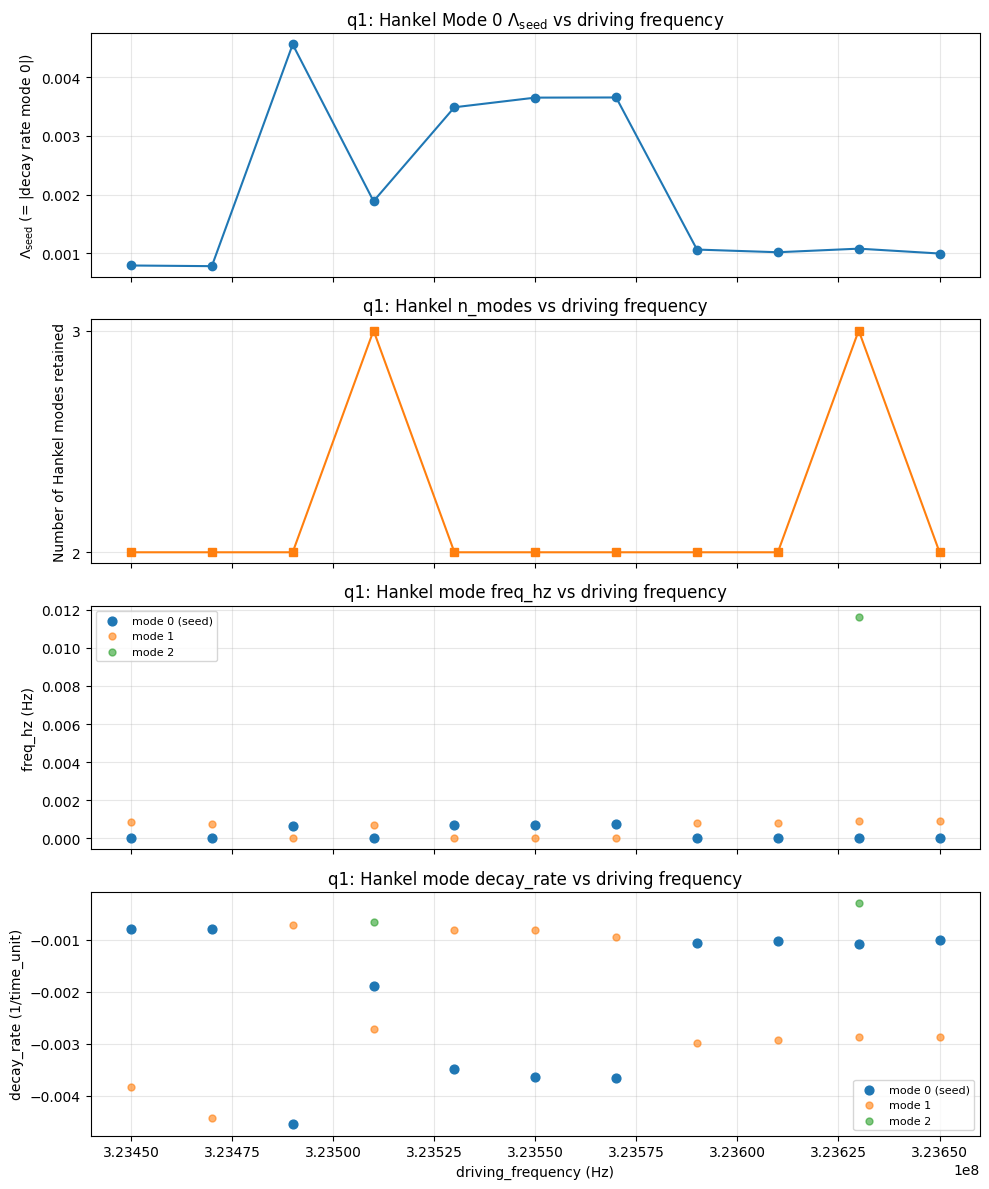

In [8]:
# --- Hankel diagnostic plots: Lambda_seed, n_modes, freq_hz, and decay_rate vs driving_frequency ---
for i, per_freq_hankel in enumerate(hankel_diagnostics):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    items_h = sorted(per_freq_hankel.items())
    freqs_h = np.array([f for f, _ in items_h])
    lambda_seeds = np.array(
        [d["Lambda_seed"] if d["Lambda_seed"] is not None else np.nan for _, d in items_h],
        dtype=float,
    )
    n_modes_arr = np.array([d["n_modes"] for _, d in items_h], dtype=int)

    # Collect per-mode-index data: mode_data[k] = {"drive_f": [], "freq_hz": [], "decay": []}
    mode_data = {}
    for f_drive, diag in items_h:
        modes = diag.get("modes", [])
        for k, mode in enumerate(modes):
            if k not in mode_data:
                mode_data[k] = {"drive_f": [], "freq_hz": [], "decay": []}
            mode_data[k]["drive_f"].append(f_drive)
            mode_data[k]["freq_hz"].append(mode.get("freq_hz", np.nan))
            mode_data[k]["decay"].append(mode.get("decay_rate", np.nan))

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    axes[0].plot(freqs_h, lambda_seeds, "o-", color="C0")
    axes[0].set_ylabel(r"$\Lambda_\mathrm{seed}$ (= |decay rate mode 0|)")
    axes[0].set_title(rf"{qname}: Hankel Mode 0 $\Lambda_\mathrm{{seed}}$ vs driving frequency")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freqs_h, n_modes_arr, "s-", color="C1")
    axes[1].set_ylabel("Number of Hankel modes retained")
    axes[1].set_title(rf"{qname}: Hankel n_modes vs driving frequency")
    axes[1].yaxis.get_major_locator().set_params(integer=True)
    axes[1].grid(True, alpha=0.3)

    for k, md in sorted(mode_data.items()):
        color = f"C{k}"
        label = f"mode {k}" + (" (seed)" if k == 0 else "")
        size = 40 if k == 0 else 25
        zorder = 3 if k == 0 else 2
        alpha = 1.0 if k == 0 else 0.6
        axes[2].scatter(md["drive_f"], md["freq_hz"], s=size, color=color, zorder=zorder, alpha=alpha, label=label)
        axes[3].scatter(md["drive_f"], md["decay"], s=size, color=color, zorder=zorder, alpha=alpha, label=label)

    axes[2].set_ylabel("freq_hz (Hz)")
    axes[2].set_title(rf"{qname}: Hankel mode freq_hz vs driving frequency")
    axes[2].legend(loc="best", fontsize=8)
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel("decay_rate (1/time_unit)")
    axes[3].set_xlabel("driving_frequency (Hz)")
    axes[3].set_title(rf"{qname}: Hankel mode decay_rate vs driving frequency")
    axes[3].legend(loc="best", fontsize=8)
    axes[3].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


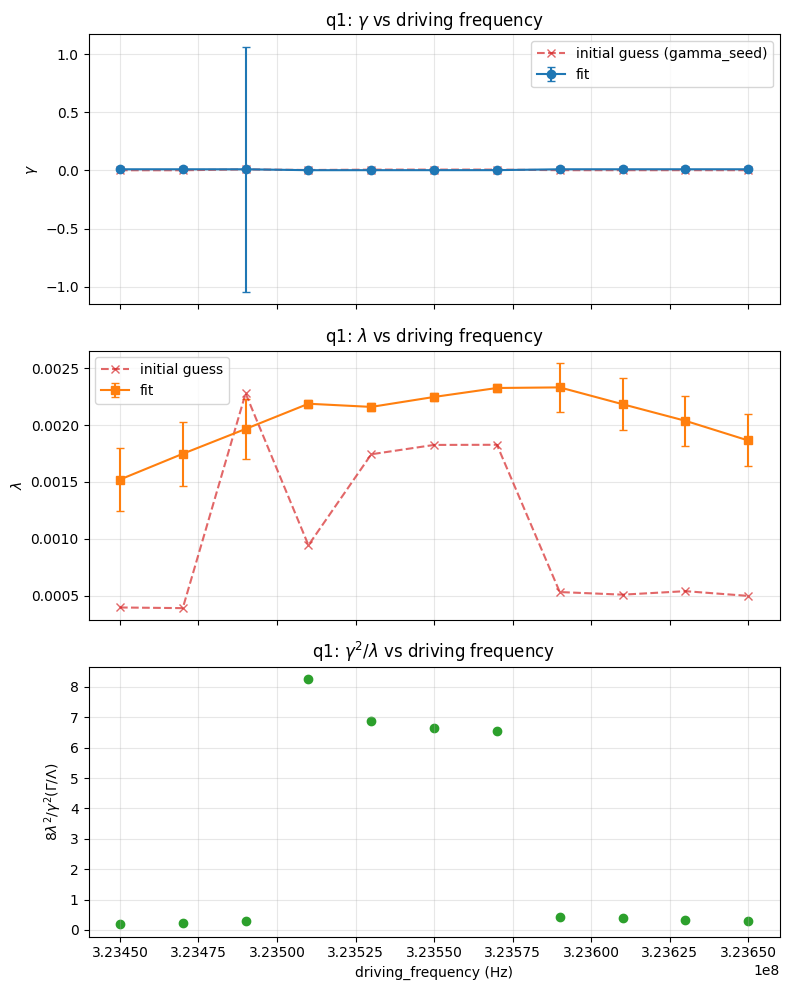

In [9]:
# --- Summary plots: gamma, lambda, and gamma/lambda vs driving_frequency, per qubit ---
for i, per_freq in enumerate(decoh_fit_results):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    items = [(f, r) for f, r in per_freq.items() if r is not None]
    if not items:
        print(f"[{qname}] no successful fits to plot.")
        continue

    items.sort(key=lambda x: x[0])
    freqs = np.array([f for f, _ in items])
    gamma = np.array([r["gamma"] for _, r in items], dtype=float)
    gamma_err = np.array([r["gamma_err"] for _, r in items], dtype=float)
    lam = np.array([r["lambda_"] for _, r in items], dtype=float)
    lam_err = np.array([r["lambda_err"] for _, r in items], dtype=float)

    # Read initial guesses stored in the decoherence-fit cell (decoh_initial_guesses)
    guess_gamma = np.array([decoh_initial_guesses[i][f]["gamma"] for f, _ in items], dtype=float)
    guess_lam = np.array([decoh_initial_guesses[i][f]["lambda_"] for f, _ in items], dtype=float)

    # gamma/lambda with simple uncertainty propagation; guard against divide-by-zero
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = 8 * lam**2 / gamma**2   # = 4*gamma^2 / lambda, which is the EP condition
    #     rel_var = (gamma_err / gamma) ** 2 + (lam_err / lam) ** 2
    #     ratio_err = np.abs(ratio) * np.sqrt(rel_var)
    # valid_ratio = np.isfinite(ratio) & np.isfinite(ratio_err)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
axes[0].errorbar(freqs, gamma, yerr=gamma_err, fmt="o-", capsize=3, label="fit")
axes[0].plot(freqs, guess_gamma, "x--", color="C3", alpha=0.7, label="initial guess (gamma_seed)")
axes[0].set_ylabel(r"$\gamma$")
axes[0].set_title(rf"{qname}: $\gamma$ vs driving frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(freqs, lam, yerr=lam_err, fmt="s-", color="C1", capsize=3, label="fit")
axes[1].plot(freqs, guess_lam, "x--", color="C3", alpha=0.7, label="initial guess")
axes[1].set_ylabel(r"$\lambda$")
axes[1].set_title(rf"{qname}: $\lambda$ vs driving frequency")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(freqs, ratio, color="C2")
axes[2].set_xlabel("driving_frequency (Hz)")
axes[2].set_ylabel(r"$8\lambda^2/\gamma^2 (\Gamma/\Lambda)$")
axes[2].set_title(rf"{qname}: $\gamma^2/\lambda$ vs driving frequency")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


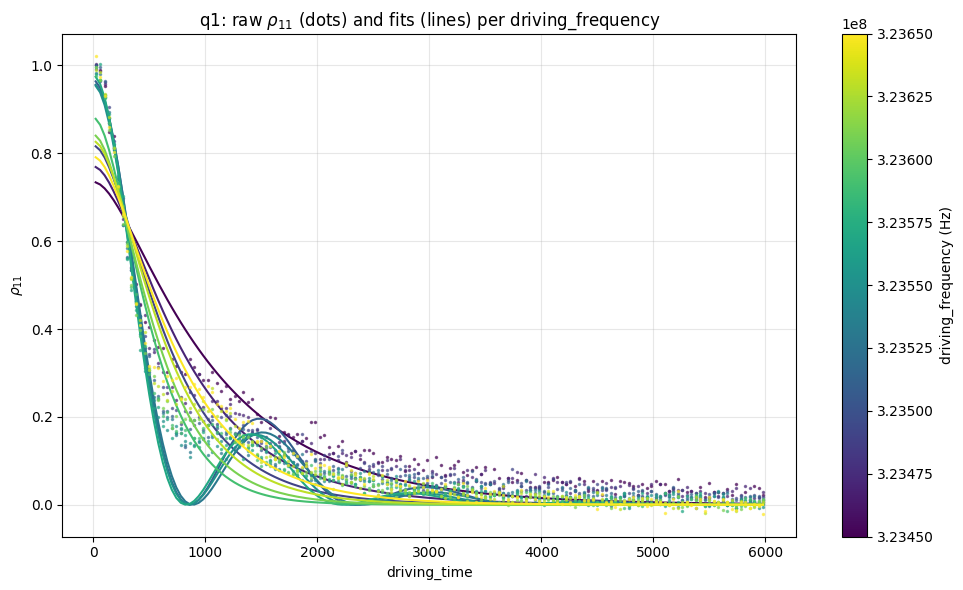

In [10]:
# --- Raw rho_11 traces and decoherence fit curves vs driving_time, colored by driving_frequency ---
for i, (rho_ds, per_freq) in enumerate(zip(rho_datasets, decoh_fit_results)):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    t = rho_ds.coords["driving_time"].values.astype(float)
    freqs_sorted = np.sort(np.array(list(per_freq.keys())))
    if len(freqs_sorted) == 0:
        continue

    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=freqs_sorted.min(), vmax=freqs_sorted.max())

    fig, ax = plt.subplots(figsize=(10, 6))
    for f_val in freqs_sorted:
        color = cmap(norm(f_val))
        y_data = rho_ds["rho_11"].sel(driving_frequency=f_val).values
        ax.plot(t, y_data, ".", ms=3, color=color, alpha=0.6)

        res = per_freq.get(f_val)
        if res is not None:
            y_fit = rho11_model(t, res["gamma"], res["lambda_"], res["rho_0"])
            ax.plot(t, y_fit, "-", lw=1.5, color=color)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("driving_frequency (Hz)")

    ax.set_xlabel("driving_time")
    ax.set_ylabel(r"$\rho_{11}$")
    ax.set_title(rf"{qname}: raw $\rho_{{11}}$ (dots) and fits (lines) per driving_frequency")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

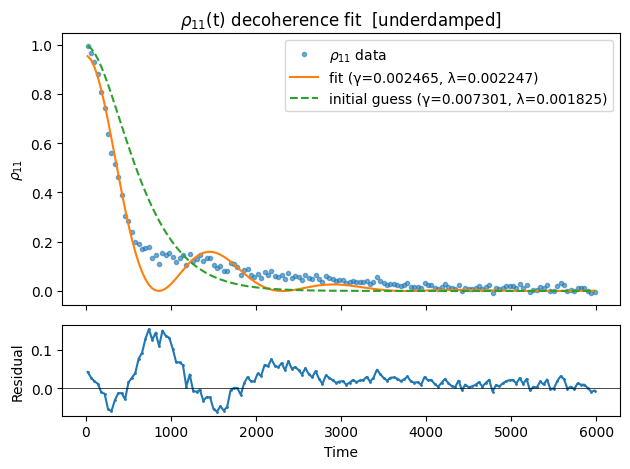

driving_frequency = 3.2355e+08 Hz
  initial guess: gamma=0.00730086, lambda=0.00182522, rho_0=0.996154
  gamma   = 0.00246486 ± 0.00011
  lambda  = 0.00224712 ± 3.5e-05
  regime  = underdamped


In [11]:
# --- Optional: inspect a single fit (data + model overlay) for one driving_frequency ---
qubit_idx = 0
target_freq = "best"  # "best" -> pick freq with minimum residual; or set a numeric value

rho_ds = rho_datasets[qubit_idx]
freqs = rho_ds.coords["driving_frequency"].values
per_freq = decoh_fit_results[qubit_idx]

if target_freq == "best":
    valid = [(f, r, r["chisqr"]) for f, r in per_freq.items() if r is not None]
    valid = [v for v in valid if np.isfinite(v[2])]
    if not valid:
        raise RuntimeError("No successful fits available to pick a 'best' frequency.")
    f_val, _, _ = min(valid, key=lambda x: x[2])
elif target_freq is None:
    f_val = freqs[len(freqs) // 2]
else:
    f_val = freqs[np.argmin(np.abs(freqs - target_freq))]

sub = rho_ds.sel(driving_frequency=f_val).rename({"driving_time": "time"})
fit_ds = sub[["rho_11"]]
results, figs = decoherence_analyzer.analyze(fit_ds)

# --- Overlay the decoherence initial guess on the rho_11 figure ---
t_init = sub.coords["time"].values.astype(float)
guess = decoh_initial_guesses[qubit_idx][float(f_val)]
g0 = guess["gamma"]
l0 = guess["lambda_"]
r0 = guess["rho_0"]
y_guess = rho11_model(t_init, g0, l0, r0)

if "rho_11" in figs:
    ax_top = figs["rho_11"].axes[0]
    ax_top.plot(t_init, y_guess, "--", color="C2", lw=1.5,
                label=f"initial guess (\u03b3={g0:.4g}, \u03bb={l0:.4g})")
    ax_top.legend()

for fig in figs.values():
    display(fig)
    plt.close(fig)

res = results["rho_11"]
print(f"driving_frequency = {f_val:.6g} Hz")
print(f"  initial guess: gamma={g0:.6g}, lambda={l0:.6g}, rho_0={r0:.6g}")
print(f"  gamma   = {res['gamma']:.6g} \u00b1 {res['gamma_err']:.2g}")
print(f"  lambda  = {res['lambda_']:.6g} \u00b1 {res['lambda_err']:.2g}")
print(f"  regime  = {res['regime']}")


## 6. Multi-Damped-Oscillation Fit (Hankel-Seeded)

Independent of the non-Markovian fit above, this section fits the same
tail-mean-subtracted $\rho_{11}(t)$ trace to a sum of damped oscillations
$$y(t) = \sum_i a_i e^{k_i t}\cos(2\pi f_i t + \phi_i) + c$$
with the number of components and the initial seeds taken directly from the
Hankel modes computed earlier. All parameters are free.

Results are stored in `mdo_fit_results[qubit_index][driving_frequency]`.

In [12]:
# --- Multi-damped-oscillation fit per driving_frequency, seeded from Hankel modes ---
# Reuses the same baseline-subtracted signal that was fed into the Hankel analyzer
# above. Number of components = number of Hankel modes retained for that frequency.

mdo_fit_results = []   # mdo_fit_results[qubit_index][driving_frequency] = result dict

def _mdo_result_dict(fitter, mr, t):
    """Package the multi-damped-oscillation fit into a plain dict."""
    if mr is None:
        return None
    modes_fit = fitter.unpack_modes(mr)
    c_fit = float(mr.params['c'].value)
    y_fit = multi_damped_osc_eval(
        t,
        [{'a': m['a'], 'k': m['k'], 'f': m['f'], 'phi': m['phi']} for m in modes_fit],
        c=c_fit,
    )
    return {
        'modes': modes_fit,
        'c': c_fit,
        'fit_curve': y_fit,
        'residuals': (mr.data - y_fit) if mr.data is not None else np.zeros_like(t),
        'chisqr': float(mr.chisqr) if mr.chisqr is not None else float('inf'),
        'success': bool(mr.success),
        'n_modes': len(modes_fit),
    }

for i, rho_ds in enumerate(rho_datasets):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    freqs_q = rho_ds.coords['driving_frequency'].values
    per_freq_mdo = {}
    n_ok_mdo = 0

    for f_val in freqs_q:
        diag = hankel_diagnostics[i].get(float(f_val), {})
        modes_seed = diag.get('modes', [])
        if not modes_seed:
            per_freq_mdo[float(f_val)] = None
            continue

        sub = rho_ds.sel(driving_frequency=f_val)
        t_arr = sub.coords['driving_time'].values.astype(float)
        y_raw = sub['rho_11'].values.astype(float)
        # Use the same baseline subtraction as the Hankel pre-analysis above.
        tail = max(int(0.1 * y_raw.size), 1)
        baseline = float(np.mean(y_raw[-tail:]))
        y_sig = y_raw - baseline

        da = xr.DataArray(y_sig, coords={'x': t_arr}, dims='x')
        try:
            fitter_mdo = FitMultiDampedOscillation(da, modes=modes_seed)
            fitter_mdo.guess()
            mr = fitter_mdo.fit()
            res = _mdo_result_dict(fitter_mdo, mr, t_arr)
            res['baseline'] = baseline  # so we can plot back on the original scale
            per_freq_mdo[float(f_val)] = res
            n_ok_mdo += 1 if res is not None and res['success'] else 0
        except Exception as exc:
            warnings.warn(f'[{qname}] f={f_val:.3e} Hz: multi-damped-osc fit failed ({exc})')
            per_freq_mdo[float(f_val)] = None

    mdo_fit_results.append(per_freq_mdo)
    print(f'[{qname}] multi-damped-osc fits succeeded: {n_ok_mdo}/{len(freqs_q)}')


[q1] multi-damped-osc fits succeeded: 11/11


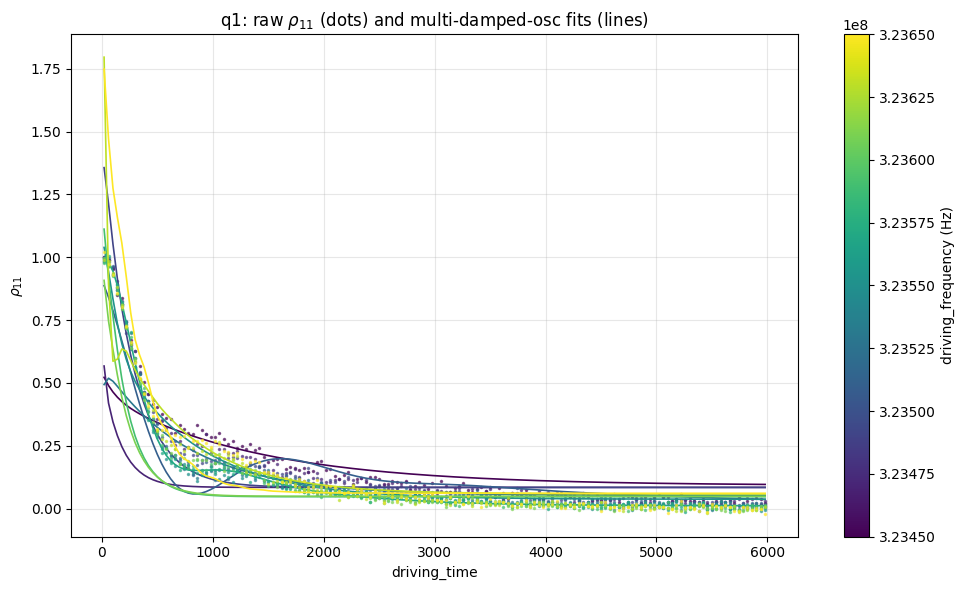

In [13]:
# --- Overlay multi-damped-oscillation fit on raw rho_11 traces, colored by driving_frequency ---
for i, (rho_ds, per_freq_mdo) in enumerate(zip(rho_datasets, mdo_fit_results)):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    t = rho_ds.coords['driving_time'].values.astype(float)
    freqs_sorted = np.sort(np.array(list(per_freq_mdo.keys())))
    if len(freqs_sorted) == 0:
        continue

    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(vmin=freqs_sorted.min(), vmax=freqs_sorted.max())

    fig, ax = plt.subplots(figsize=(10, 6))
    for f_val in freqs_sorted:
        color = cmap(norm(f_val))
        y_data = rho_ds['rho_11'].sel(driving_frequency=f_val).values
        ax.plot(t, y_data, '.', ms=3, color=color, alpha=0.6)

        res = per_freq_mdo.get(f_val)
        if res is not None:
            # fit_curve is on the baseline-subtracted signal; add baseline back for display.
            ax.plot(t, res['fit_curve'] + res.get('baseline', 0.0), '-', lw=1.2, color=color)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('driving_frequency (Hz)')

    ax.set_xlabel('driving_time')
    ax.set_ylabel(r'$\rho_{11}$')
    ax.set_title(rf'{qname}: raw $\rho_{{11}}$ (dots) and multi-damped-osc fits (lines)')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


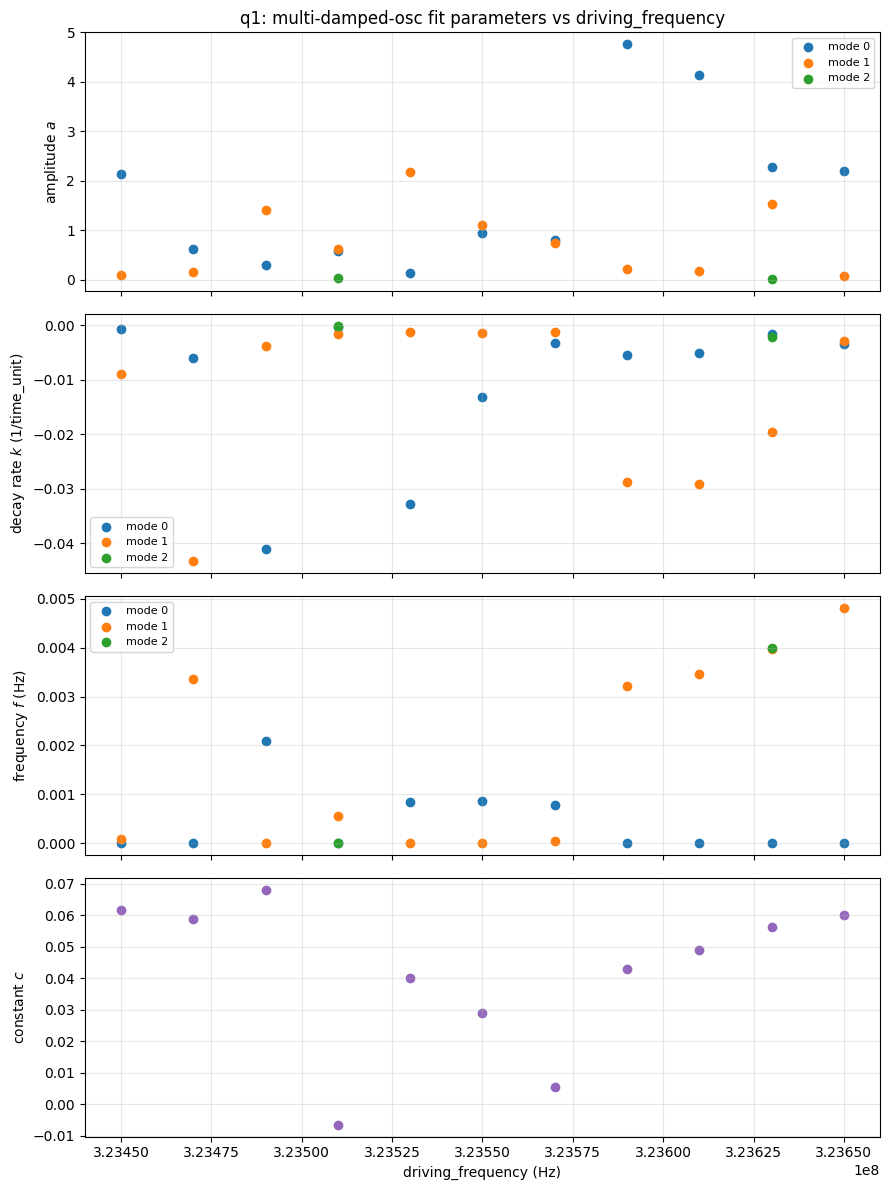

In [14]:
# --- Per-mode parameter summary from the multi-damped-osc fit vs driving_frequency ---
for i, per_freq_mdo in enumerate(mdo_fit_results):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    items = sorted([(f, r) for f, r in per_freq_mdo.items() if r is not None])
    if not items:
        print(f'[{qname}] no successful multi-damped-osc fits.')
        continue

    # Group by mode index (mode 0 = largest-amplitude in the Hankel seed ordering).
    mode_data = {}
    for f_drive, r in items:
        for k, m in enumerate(r['modes']):
            mode_data.setdefault(k, {'drive_f': [], 'a': [], 'k_decay': [], 'f_hz': []})
            mode_data[k]['drive_f'].append(f_drive)
            mode_data[k]['a'].append(m['a'])
            mode_data[k]['k_decay'].append(m['k'])
            mode_data[k]['f_hz'].append(m['f'])

    # Collect c (constant offset) per driving_frequency
    c_drive_f = [f_drive for f_drive, r in items]
    c_vals = [r['c'] for _, r in items]

    fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)
    for k, md in sorted(mode_data.items()):
        color = f'C{k}'
        label = f'mode {k}'
        axes[0].scatter(md['drive_f'], md['a'], color=color, label=label)
        axes[1].scatter(md['drive_f'], md['k_decay'], color=color, label=label)
        axes[2].scatter(md['drive_f'], md['f_hz'], color=color, label=label)

    axes[3].scatter(c_drive_f, c_vals, color='C4')

    axes[0].set_ylabel('amplitude $a$')
    axes[0].set_title(f'{qname}: multi-damped-osc fit parameters vs driving_frequency')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel('decay rate $k$ (1/time_unit)')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_ylabel('frequency $f$ (Hz)')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel('constant $c$')
    axes[3].set_xlabel('driving_frequency (Hz)')
    axes[3].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


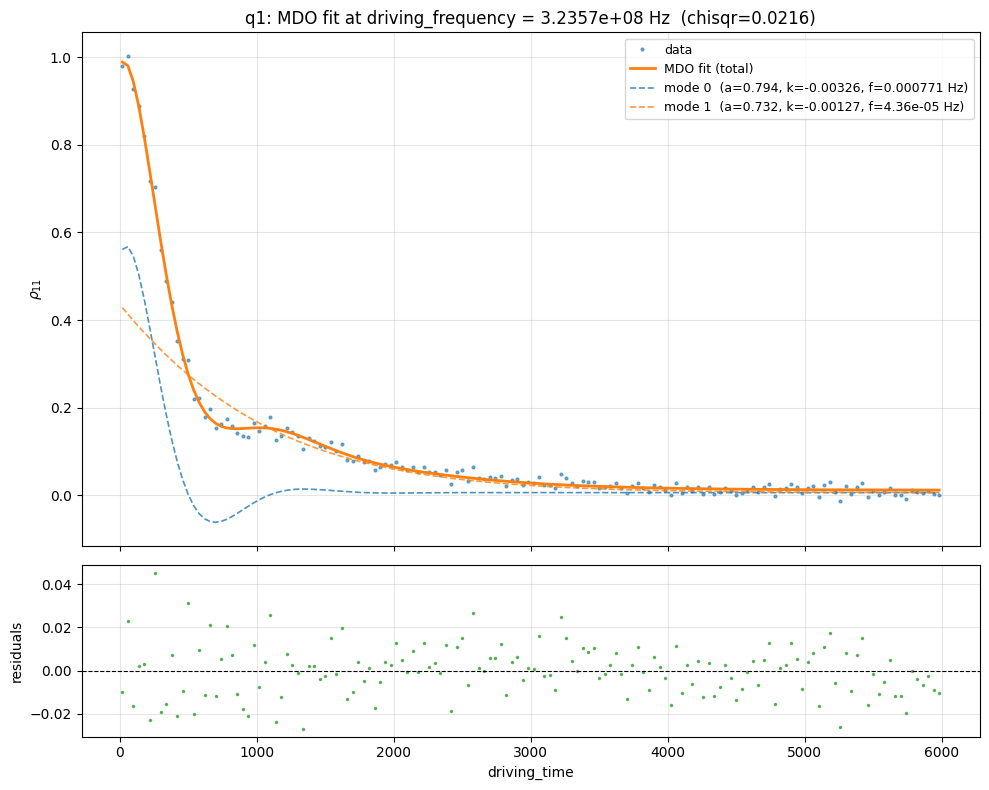

driving_frequency = 3.2357e+08 Hz
  n_modes = 2,  chisqr = 0.0216
  mode 0: a=0.7943,  k=-0.003265 (1/time_unit),  f=0.0007708 Hz,  phi=-0.8252 rad
  mode 1: a=0.7322,  k=-0.001266 (1/time_unit),  f=4.359e-05 Hz,  phi=-0.9429 rad
  c (offset) = 0.005553


In [15]:

# --- Optional: inspect a single MDO fit (data + model overlay) for one driving_frequency ---
qubit_idx = 0
target_freq_mdo = "best"  # "best" -> pick freq with minimum chisqr; or set a numeric value

rho_ds = rho_datasets[qubit_idx]
per_freq_mdo = mdo_fit_results[qubit_idx]

if target_freq_mdo == "best":
    valid = [(f, r) for f, r in per_freq_mdo.items() if r is not None and np.isfinite(r["chisqr"])]
    if not valid:
        raise RuntimeError("No successful MDO fits available.")
    f_val, _ = min(valid, key=lambda x: x[1]["chisqr"])
elif target_freq_mdo is None:
    freqs = rho_ds.coords["driving_frequency"].values
    f_val = freqs[len(freqs) // 2]
else:
    freqs = rho_ds.coords["driving_frequency"].values
    f_val = freqs[np.argmin(np.abs(freqs - target_freq_mdo))]

try:
    qname = qubit_data[qubit_idx]["qubit"].values.item() if "qubit" in qubit_data[qubit_idx] else f"Dataset_{qubit_idx}"
except Exception:
    qname = f"Dataset_{qubit_idx}"

sub = rho_ds.sel(driving_frequency=f_val)
t = sub.coords["driving_time"].values.astype(float)
y_raw = sub["rho_11"].values.astype(float)

res = per_freq_mdo[float(f_val)]
baseline = res.get("baseline", 0.0)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# Top: data + total fit + per-mode contributions
axes[0].plot(t, y_raw, ".", ms=4, color="C0", alpha=0.6, label="data")
axes[0].plot(t, res["fit_curve"] + baseline, "-", lw=2, color="C1", label="MDO fit (total)")

for k, mode in enumerate(res["modes"]):
    y_mode = multi_damped_osc_eval(
        t,
        [{"a": mode["a"], "k": mode["k"], "f": mode["f"], "phi": mode["phi"]}],
        c=0.0,
    )
    axes[0].plot(
        t, y_mode + baseline, "--", lw=1.2, alpha=0.8,
        label=f"mode {k}  (a={mode['a']:.3g}, k={mode['k']:.3g}, f={mode['f']:.3g} Hz)",
    )

axes[0].set_ylabel(r"$\rho_{11}$")
axes[0].set_title(
    rf"{qname}: MDO fit at driving_frequency = {f_val:.6g} Hz  (chisqr={res['chisqr']:.4g})"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: residuals
axes[1].plot(t, res["residuals"], ".", ms=3, color="C2", alpha=0.7)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel("driving_time")
axes[1].set_ylabel("residuals")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"driving_frequency = {f_val:.6g} Hz")
print(f"  n_modes = {res['n_modes']},  chisqr = {res['chisqr']:.4g}")
for k, m in enumerate(res["modes"]):
    print(f"  mode {k}: a={m['a']:.4g},  k={m['k']:.4g} (1/time_unit),  f={m['f']:.4g} Hz,  phi={m['phi']:.4g} rad")
print(f"  c (offset) = {res['c']:.4g}")


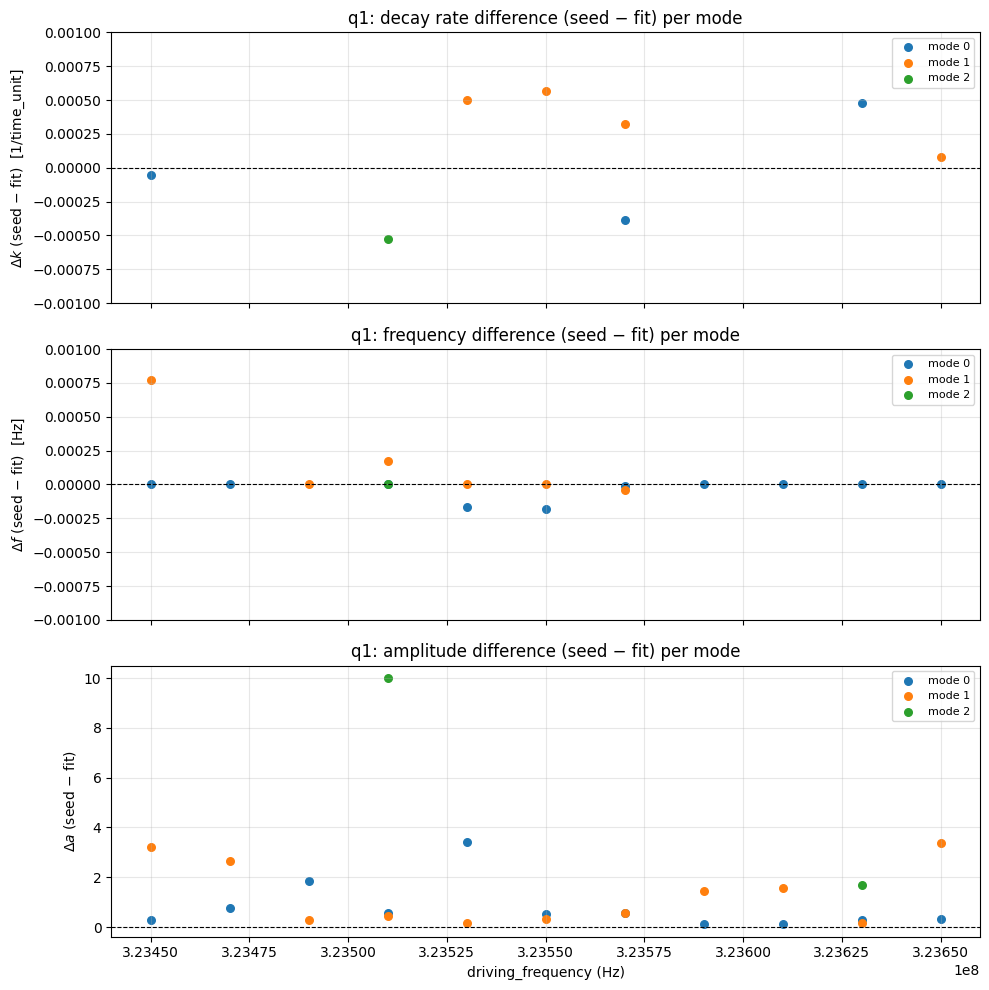

In [19]:

# --- Difference (seed - fit) for k_decay and f_hz per mode vs driving_frequency ---
for i, per_freq_mdo in enumerate(mdo_fit_results):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    items = sorted([(f, r) for f, r in per_freq_mdo.items() if r is not None])
    if not items:
        print(f'[{qname}] no successful multi-damped-osc fits.')
        continue

    max_modes = max(r['n_modes'] for _, r in items)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    for k in range(max_modes):
        color = f'C{k}'
        label = f'mode {k}'

        drive_f_diff, dk_diff, df_diff, da_diff = [], [], [], []

        for f_drive, r in items:
            if k >= r['n_modes']:
                continue
            diag = hankel_diagnostics[i].get(float(f_drive), {})
            seed_modes = diag.get('modes', [])
            if k >= len(seed_modes):
                continue

            k_fit_val = r['modes'][k]['k']
            f_fit_val = r['modes'][k]['f']
            a_fit_val = r['modes'][k]['a']
            k_seed_val = seed_modes[k].get('decay_rate', np.nan)
            f_seed_val = seed_modes[k].get('freq_hz', np.nan)
            a_seed_val = seed_modes[k].get('amplitude', np.nan)

            drive_f_diff.append(f_drive)
            dk_diff.append(k_seed_val - k_fit_val)
            df_diff.append(f_seed_val - f_fit_val)
            da_diff.append(a_seed_val / a_fit_val)

        if drive_f_diff:
            axes[0].scatter(drive_f_diff, dk_diff, color=color, marker='o', s=30, label=label)
            axes[1].scatter(drive_f_diff, df_diff, color=color, marker='o', s=30, label=label)
            axes[2].scatter(drive_f_diff, da_diff, color=color, marker='o', s=30, label=label)

    axes[0].axhline(0, color='k', lw=0.8, ls='--')
    axes[0].set_ylabel(r'$\Delta k$ (seed $-$ fit)  [1/time_unit]')
    axes[0].set_title(f'{qname}: decay rate difference (seed − fit) per mode')
    axes[0].set_ylim(-0.001, 0.001)
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(0, color='k', lw=0.8, ls='--')
    axes[1].set_ylabel(r'$\Delta f$ (seed $-$ fit)  [Hz]')
    axes[1].set_title(f'{qname}: frequency difference (seed − fit) per mode')
    axes[1].set_ylim(-0.001, 0.001)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    axes[2].axhline(0, color='k', lw=0.8, ls='--')
    axes[2].set_ylabel(r'$\Delta a$ (seed $-$ fit)')
    axes[2].set_xlabel('driving_frequency (Hz)')
    axes[2].set_title(f'{qname}: amplitude difference (seed − fit) per mode')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
